# 04 — Clusters de vulnerabilidade

`KMeans` sobre a forma da distribuição de proficiência (`pct_nivel_0..8`, 2024) e seis variáveis de contexto, padronizadas; k escolhido por silhueta. Leitura estratégica, não modelo preditivo. Lê `reports/` (`python -m src.modeling.clusters`).

In [1]:
import sys; sys.path.insert(0, "..")
import pandas as pd

from src import config
from src.visualization import plots
from IPython.display import Image, display

pd.set_option("display.width", 160)
NOMES = {0: 'cauda crítica', 1: 'alto desempenho', 2: 'intermediário urbano'}  # rótulo dado à mão depois de olhar os perfis -- o número do cluster (0/1/2) é só o id que o KMeans deu, não tem ordem nem significado sozinho
aval = pd.read_csv(config.REPORTS / "avaliacao_k.csv")
perfis = pd.read_csv(config.REPORTS / "perfis_clusters.csv")
cm = pd.read_csv(config.REPORTS / "clusters_municipios.csv")
mun = pd.read_parquet(config.PROCESSED / "base_modelagem_municipio.parquet")
display(aval.round(3))

C:\Users\tcarm\Projetos\predicao-alfabetiza-brasil\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,k,inercia,silhueta
0,2,66117.037,0.192
1,3,58353.210,0.203
2,4,52791.329,0.167
3,5,49412.585,0.149
4,6,45555.052,0.153
5,7,43125.067,0.143
6,8,41345.605,0.137


## 1. Perfis

,cluster,nome,n,taxa_media,criancas_nao_alfabetizadas,regiao_dominante,pct_regiao_dominante,pct_nivel_0,pct_nivel_1,pct_nivel_2,taxa_alfabetizacao_adultos,log_pib_per_capita,pct_escolas_rurais,tdi_ai
0,0,cauda crítica,2041,43.17,443830.0,Nordeste,0.57,3.93,7.53,12.80,0.85,9.92,0.60,20.26
1,1,alto desempenho,413,91.00,7598.0,Nordeste,0.74,0.43,0.59,1.42,0.82,9.78,0.52,19.54
2,2,intermediário urbano,2996,72.26,301523.0,Sudeste,0.43,1.26,2.41,4.80,0.91,10.47,0.32,19.77


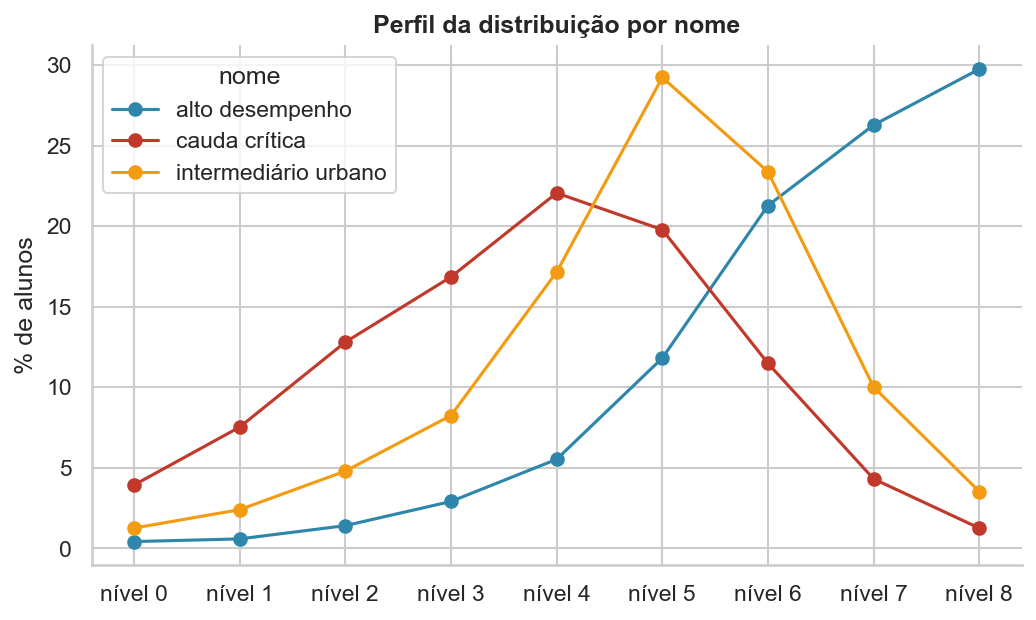

In [2]:
perfis["nome"] = perfis["cluster"].map(NOMES)
display(perfis[["cluster", "nome", "n", "taxa_media", "criancas_nao_alfabetizadas", "regiao_dominante", "pct_regiao_dominante",
                "pct_nivel_0", "pct_nivel_1", "pct_nivel_2", "taxa_alfabetizacao_adultos", "log_pib_per_capita", "pct_escolas_rurais", "tdi_ai"]].round(2))
m24 = mun[mun["ano"] == 2024].merge(cm[["id_municipio", "cluster"]], on="id_municipio")  # o cluster foi calculado só com o corte de 2024, então junta de volta só esse ano
m24["nome"] = m24["cluster"].map(NOMES)
caminho = plots.salvar(plots.plot_perfis_niveis(m24, "nome"), "clusters_perfis_niveis")
display(Image(filename=str(caminho)))

## 2. Onde estão

regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
nome,,,,,
alto desempenho,7.3,73.6,0.5,17.4,1.2
cauda crítica,3.2,56.7,14.9,12.3,12.8
intermediário urbano,12.3,10.6,4.3,43.5,29.3


alunos_com_nota,<Q1,Q1–Q2,Q2–Q3,>Q3
nome,,,,
alto desempenho,29.1,23.0,23.5,24.5
cauda crítica,20.6,24.3,26.8,28.3
intermediário urbano,27.8,25.9,23.7,22.6


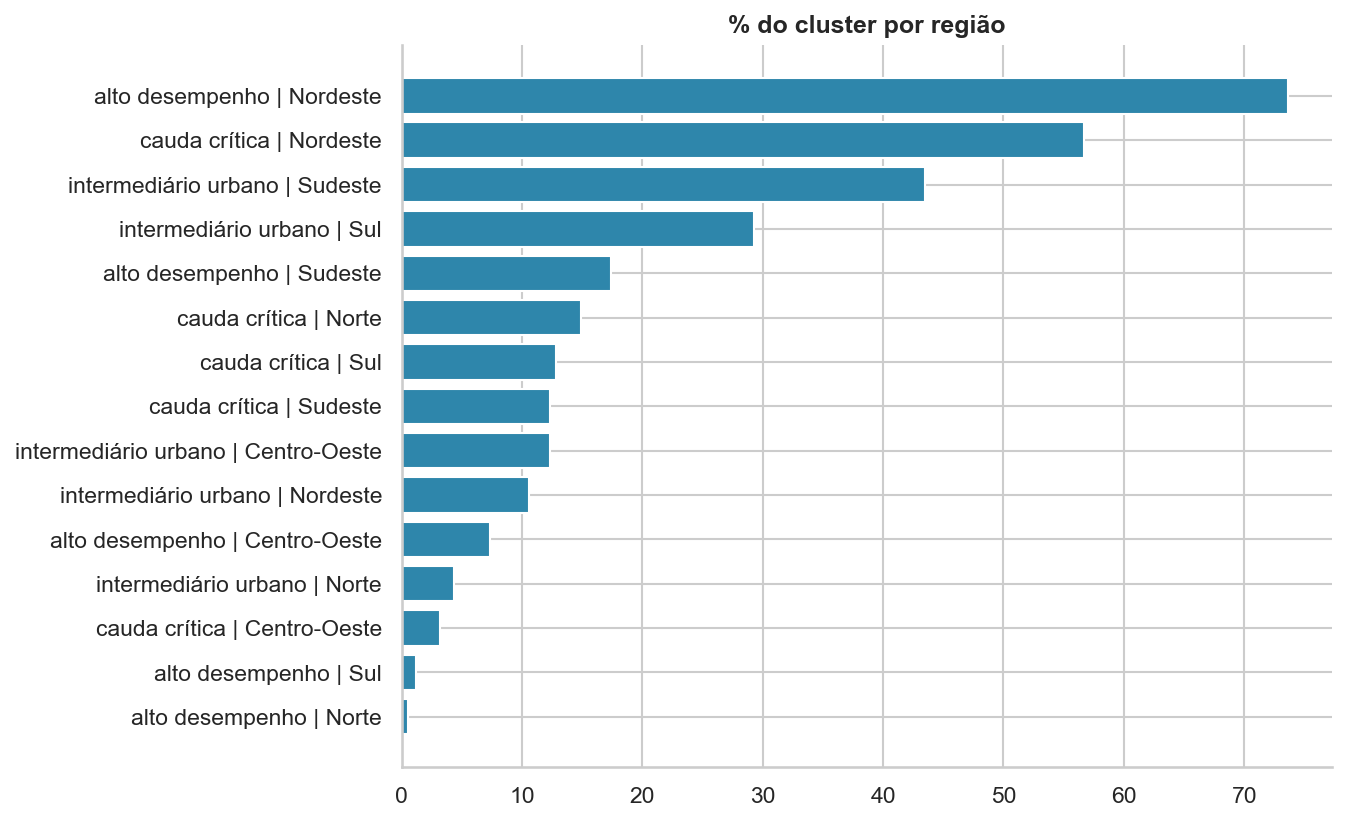

In [3]:
ct = pd.crosstab(m24["nome"], m24["regiao"], normalize="index").mul(100).round(1)  # normalize="index" dá % dentro de cada cluster (linha soma 100), não % do total geral
display(ct)
porte = pd.qcut(m24["alunos_com_nota"], 4, labels=["<Q1", "Q1–Q2", "Q2–Q3", ">Q3"])
display(pd.crosstab(m24["nome"], porte, normalize="index").mul(100).round(1))
caminho = plots.salvar(plots.plot_barras_horizontais(ct.stack().reset_index().rename(columns={0: "pct"}).assign(feature=lambda d: d["nome"] + " | " + d["regiao"]), "pct", top=30, titulo="% do cluster por região"), "clusters_por_regiao")
display(Image(filename=str(caminho)))

## 3. Clusters como carteiras de intervenção

Cada perfil pede uma ação diferente: onde a cauda crítica (`pct_nivel_0..2`) domina, o problema é de base e a resposta é intensiva; onde a massa está "quase lá" (`pct_quase_la` alto), o ganho por criança é rápido; onde o contexto é rural e disperso, a logística é a barreira. Cruzado com o ranking do notebook 03, dá a lista de *quem* e o perfil de *como*.